In [126]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
conn = sqlite3.connect("../data/themepark.db")

In [128]:
# QUERY 1: Weather Impact on Guest Spending
weather_query = """
SELECT
  w.condition_code,
  ROUND(AVG(p.amount_cents_clean / 100.0)) AS avg_purchase_usd,
  COUNT(p.purchase_id) AS total_purchases
FROM dim_weather w
JOIN fact_visits v ON v.date_id = w.date_id
JOIN fact_purchases p ON p.visit_id = v.visit_id
GROUP BY w.condition_code
ORDER BY avg_purchase_usd DESC;
"""
df_weather = pd.read_sql_query(weather_query, conn)

In [129]:
df_weather.head()

,condition_code,avg_purchase_usd,total_purchases
0,Partly Cloudy,26.0,39
1,Clear,26.0,13
2,Cloudy,25.0,3
3,Rain,24.0,8


In [130]:

# ── Style constants (consistent with existing project figures) ──
BG_DARK = '#ffff' #1B2A3D
CARD_BG = '#ffff' #243447
AMBER = '#F4A261'
TEAL = '#2A9D8F'
CORAL = '#E76F51'
GREEN = '#57CC99'
BLUE = '#457B9D'
TEXT_PRIMARY = '#1B2A3D'
TEXT_SECONDARY = '#243447'
TEXT_MUTED = '#78909C'
 
plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor': CARD_BG,
    'axes.edgecolor': TEXT_MUTED,
    'axes.labelcolor': TEXT_SECONDARY,
    'xtick.color': TEXT_SECONDARY,
    'ytick.color': TEXT_SECONDARY,
    'text.color': TEXT_PRIMARY,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.grid': True,
    'grid.color': '#2F4562',
    'grid.alpha': 0.5,
    'grid.linewidth': 0.5,
})

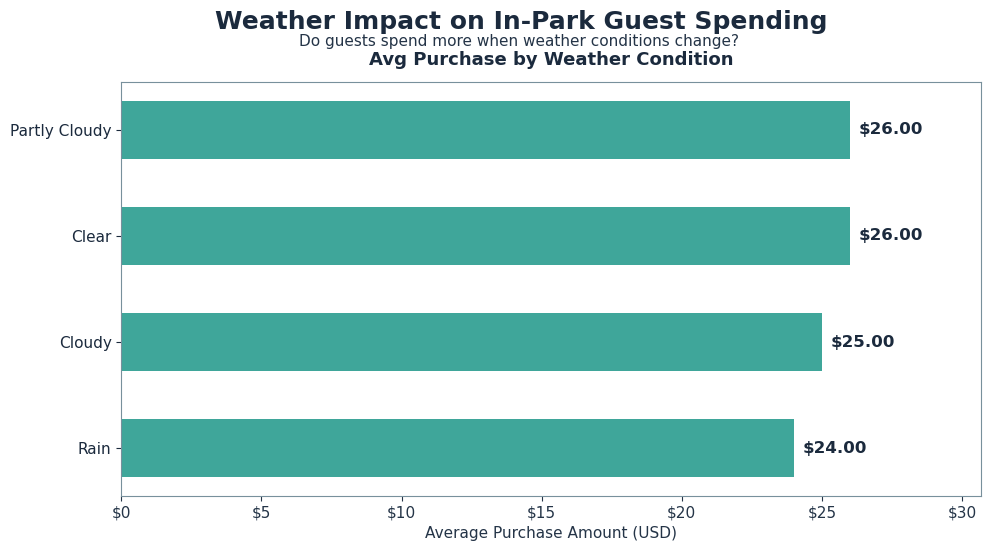

In [131]:
fig1, ax1a = plt.subplots(ncols=1, figsize=(10, 6), sharey=True)
fig1.suptitle('Weather Impact on In-Park Guest Spending',
              fontsize=18, fontweight='bold', color=TEXT_PRIMARY, y=0.97)
fig1.text(0.5, 0.91,
          'Do guests spend more when weather conditions change? ',
          ha='center', fontsize=11, color=TEXT_SECONDARY)
 
# Color mapping by weather condition
weather_colors = {
    'Clear': TEAL, 'Partly Cloudy': TEAL,
    'Cloudy': TEAL, 'Rain': TEAL
}
colors = [weather_colors.get(c, TEAL) for c in df_weather['condition_code']]
 
# Left: Horizontal bar chart — avg purchase by condition
bars = ax1a.barh(df_weather['condition_code'], df_weather['avg_purchase_usd'],
                 color=colors, edgecolor='none', height=0.55, alpha=0.9)
 
for bar, val in zip(bars, df_weather['avg_purchase_usd']):
    ax1a.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
              f'${val:.2f}', va='center', fontsize=12, fontweight='bold',
              color=TEXT_PRIMARY)
 
ax1a.set_xlabel('Average Purchase Amount (USD)', fontsize=11, color=TEXT_SECONDARY)
ax1a.set_title('Avg Purchase by Weather Condition', fontsize=13,
               fontweight='bold', color=TEXT_PRIMARY, pad=12)
ax1a.set_xlim(0, max(df_weather['avg_purchase_usd']) * 1.18)
ax1a.invert_yaxis()
ax1a.tick_params(axis='y', labelsize=11, colors=TEXT_PRIMARY)
ax1a.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax1a.grid(False) 

 
fig1.subplots_adjust(top=0.85, bottom=0.16, left=0.10, right=0.96, wspace=0.35)
plt.savefig('/Users/Marcy_Student/Desktop/Marcy_Projects/Mod3_Final_Project-Theme-Park-Analytics/figures/weather_impact_on_spending.png', dpi=300, bbox_inches='tight')

In [132]:
# QUERY 2: Emergency Maintenance vs Guest Spending
maintenance_spend_query = """
SELECT
  CASE
    WHEN em.date_id IS NOT NULL THEN 'Emergency\nMaintenance Day'
    ELSE 'Normal Day'
  END AS day_type,
  COUNT(DISTINCT v.visit_id) AS visits,
  ROUND(AVG(v.spend_cents_clean / 100.0), 2) AS avg_spend_usd
FROM fact_visits v
LEFT JOIN (
  SELECT DISTINCT date_id FROM fact_maintenance WHERE maintenance_type = 'Emergency'
) em ON em.date_id = v.date_id
WHERE v.spend_cents_clean IS NOT NULL
GROUP BY day_type;
"""
df_maint_spend = pd.read_sql_query(maintenance_spend_query, conn)
 
conn.close()

In [133]:
df_maint_spend.head()

,day_type,visits,avg_spend_usd
0,Emergency\nMaintenance Day,6,92.57
1,Normal Day,31,132.02


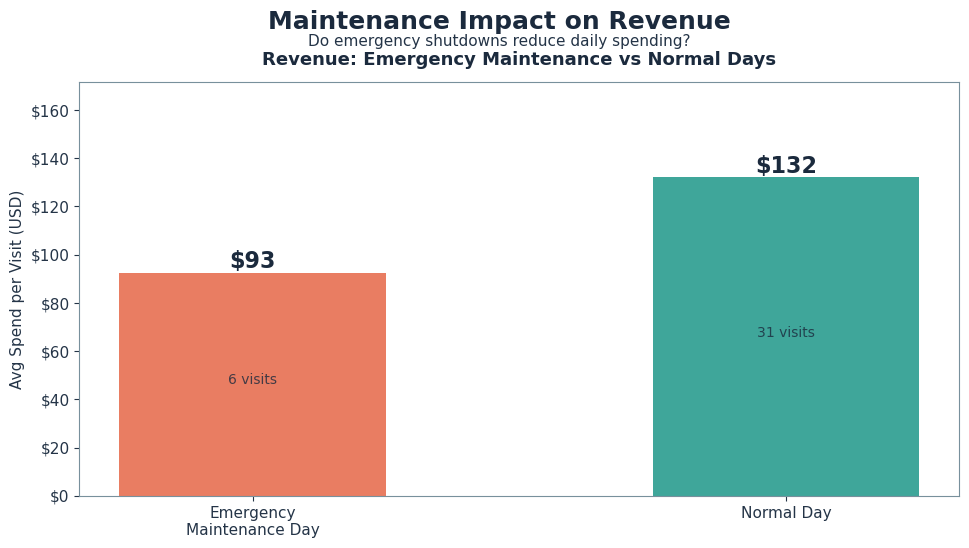

In [134]:
fig2, ax2b = plt.subplots(figsize=(10, 6))
fig2.suptitle('Maintenance Impact on Revenue',
              fontsize=18, fontweight='bold', color=TEXT_PRIMARY, y=0.97)
fig2.text(0.5, 0.91,
          'Do emergency shutdowns reduce daily spending?',
          ha='center', fontsize=11, color=TEXT_SECONDARY)

 
# ── Right panel: Emergency maintenance vs spending ──
spend_colors = [CORAL, TEAL]
spend_bars = ax2b.bar(df_maint_spend['day_type'], df_maint_spend['avg_spend_usd'],
                      color=spend_colors, edgecolor='none', width=0.5, alpha=0.9)
 
for bar, val, visits in zip(spend_bars, df_maint_spend['avg_spend_usd'],
                            df_maint_spend['visits']):
    ax2b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
              f'${val:.0f}', ha='center', fontsize=16, fontweight='bold',
              color=TEXT_PRIMARY)
    ax2b.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
              f'{visits} visits', ha='center', fontsize=10,
              color=TEXT_PRIMARY, alpha=0.8)
 
ax2b.set_ylabel('Avg Spend per Visit (USD)', fontsize=11, color=TEXT_SECONDARY)
ax2b.set_title('Revenue: Emergency Maintenance vs Normal Days', fontsize=13,
               fontweight='bold', color=TEXT_PRIMARY, pad=12)
ax2b.set_ylim(0, max(df_maint_spend['avg_spend_usd']) * 1.3)
ax2b.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
 
ax2b.grid(False) 
fig2.subplots_adjust(top=0.85, bottom=0.16, left=0.08, right=0.96, wspace=0.30)
fig2.savefig('/Users/Marcy_Student/Desktop/Marcy_Projects/Mod3_Final_Project-Theme-Park-Analytics/figures/maintenance_impact_analysis.png',
             dpi=300, bbox_inches='tight')
plt.show()